### When we will refer to the loss, we refer in fact to the combined loss we defined in the losses.py file. This is the loss function we used to train our models.

In [37]:
%load_ext autoreload
%autoreload 2

from models import U_Net, AttU_Net
from train import train_2D, test_2D, test_3D
# Import of the libraries and functions

from utils import compare_predictions_ground_truth, prepare_data, graph, predict_volume, load_slice, GradCAM, overlay_cam, saliency_map
from torch.utils.data import TensorDataset, DataLoader
import nibabel as nib
import torch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### We trained the models on Google Colab because it was quicker so we only have the results to show on this notebook.

At the very beginning, we did the split of the data directly in the training function :

In [ ]:
# This function is not valid anymore as we modified it to take directly the train_loader and the validation_loader in parameters
# However, we still wanted to show it because we obtained interesting results with it

train_loss, validation_losses, test_loss = train_2D(
    model= U_Net(1, 5),
    name ="U_Net_weights30",
    train_size=14,
    validation_size=2,
    test_size=4,
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

The losses obtained with this function for the U-Net were :

![](loss_images/U_Net_30_epochs.png)

Unfortunately, we no longer have the loss value for this U-Net on the test set. Moreover, even if we did, it wouldn’t be very informative, since we wouldn’t be able to compare it with the Attention U-Net’s loss due to differences in the test sets.

In [ ]:
# This function is not valid anymore as we modified it to take directly the train_loader and the validation_loader in parameters
# However, we still wanted to show it because we obtained interesting results with it
# We provide the code we used to get the results so that you can have access to the parameters we used

train_loss, validation_losses, test_loss = train_2D(
    model= AttU_Net(1, 5),
    name ="Att_U_Net_weights30",
    train_size=14,
    validation_size=2,
    test_size=4,
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

The losses obtained with this function for the Attention U-Net were :

![](loss_images/Att_U_Net_30.png)

And the loss on the test set was 0.1648.

#### In order to be able to compare the performances between the U-Net and the Attention U-Net, we define the training, validation and test set outside the training function such that we train the models with the same sets

In [45]:
(X_train_tensor,
X_validation_tensor,
X_test_tensor,
y_train_tensor,
y_validation_tensor,
y_test_tensor,
X_test_3D,
y_test_3D) = prepare_data(train_size = 14, validation_size=2, rand = True, data_path="data")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

validation_dataset = TensorDataset(X_validation_tensor, y_validation_tensor)
validation_loader = DataLoader(validation_dataset, batch_size=4, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True)

X_train.shape :  (459, 1, 256, 256)
X_validation.shape :  (63, 1, 256, 256)
X_test.shape :  (125, 1, 256, 256)


Then, we train the U-Net with the training, validation and test sets we defined in the previous cell.

In [ ]:
train_loss_u_net, validation_losses_u_net = train_2D(
    model=U_Net(1, 5),
    train_loader=train_loader,
    validation_loader=validation_loader,
    name ="U_Net_weights30_V2",
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

We also train the Attention U-Net with the same sets.

In [ ]:
train_loss_attention_u_net, validation_losses_attention_u_net = train_2D(
    model=AttU_Net(1, 5),
    train_loader=train_loader,
    validation_loader=validation_loader,
    name ="Att_U_Net_weights30_V2",
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

And we plot the loss figures to compare the performances of the two models.

![](loss_images/Loss_comparison_between_U-net_and_Attention-U-Net.png)

We notice that the loss functions from the U-Net and the Attention U-Net are very close. We also see that the loss is generally higher for the Attention U-Net at the beginning of the training. The two losses tends towards the same limits and the difference of performances between the two models are not clearly visible.

In [ ]:
test_loss,dice_classes = test_2D(
    model=U_Net(1, 5),
    test_loader=test_loader,
    name ="U_Net_weights30_V2"
)

In [62]:
test_loss,dice_classes = test_2D(
    model=AttU_Net(1,5),
    test_loader=test_loader,
    name ="models/attU_Net_weights100"
)

Loss on test dataset: 0.1405
Dice per class on test dataset: [0.99642685 0.89546959 0.56651685 0.5992114  0.68888209]


In [61]:
test_3D(AttU_Net(1,5), X_test_3D, y_test_3D, "models/attU_Net_weights100")

tensor([0.9967, 0.9367, 0.7073, 0.7162, 0.8825])

When we compare the losses on the test dataset for the two models, we notice that we have a slightly higher loss for the Attention U-Net, which seems confusing as the Attention U-Net is supposed to improve the performance. We also notice that the value of the loss is around 0.075 while we had a loss of approximately 0.2 on the training set for the models so this is also pretty weird.

In [61]:
model = AttU_Net(1,5)
import torch
model.load_state_dict(torch.load("models/attU_Net_weights10.pth"))

<All keys matched successfully>

In [9]:
print(X_test_3D[0].shape)
out = model.forward_volume(X_test_3D[0])

print(out.shape)

torch.Size([30, 256, 256])
torch.Size([30, 5, 256, 256])


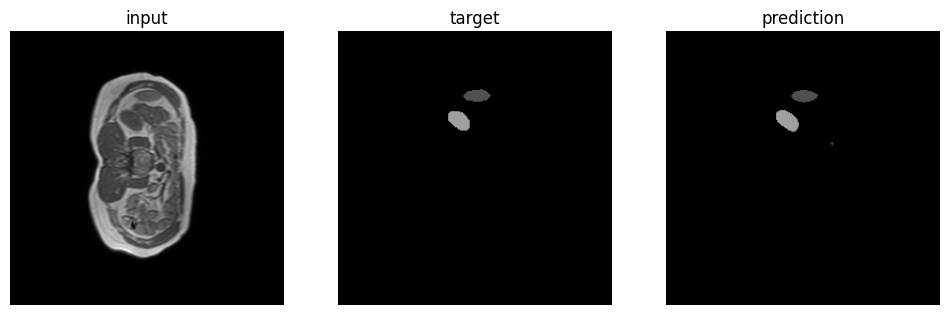

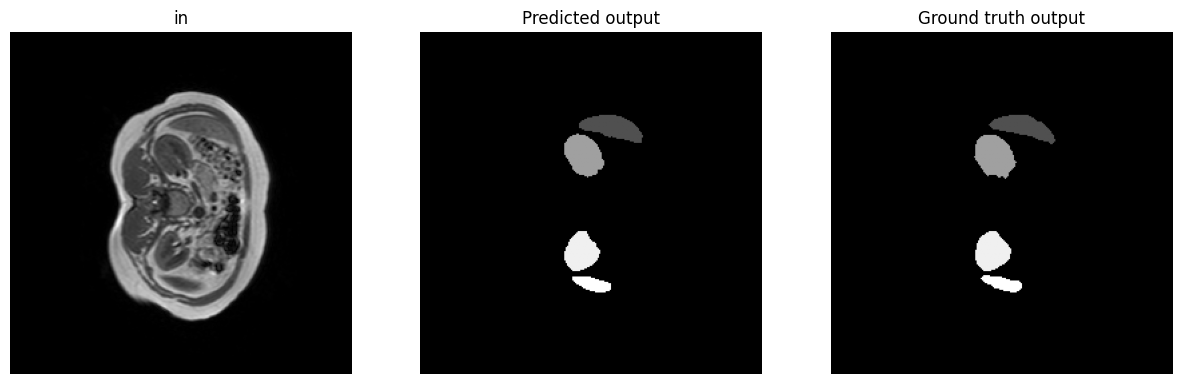

In [73]:
compare_predictions_ground_truth(AttU_Net(1,5), "Att_U_Net_weights30_V2.pth", "data/MR-dataset/34-T1DUALin-src.nii.gz", "data/MR-dataset/34-T1DUAL-mask.nii.gz")

In [12]:
nifti_out, volume = predict_volume(U_Net(1,5), "U_Net_weights30.pth", "data/MR-dataset/01-T1DUALin-src.nii.gz")

In [13]:
save_path = "reconstructed_volumes/predicted_mask_01-T1DUAL_U_Net.nii.gz"
nib.save(nifti_out, save_path)

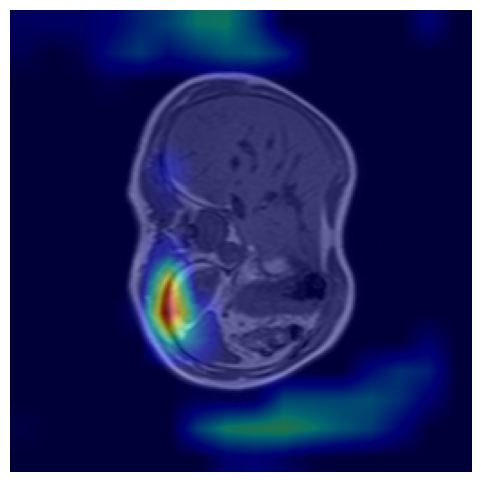

In [35]:
model = U_Net(1,5)
model.load_state_dict(torch.load("U_Net_weights30_V2.pth", map_location = torch.device('cpu')))

target_layer = model.Conv5

cam = GradCAM(model, target_layer)

image = load_slice("data/MR-dataset/01-T1DUALin-src.nii.gz", 30)

# image : (1,1,H,W)
heatmap = cam(image, class_idx=3)

overlay_cam(image, heatmap)

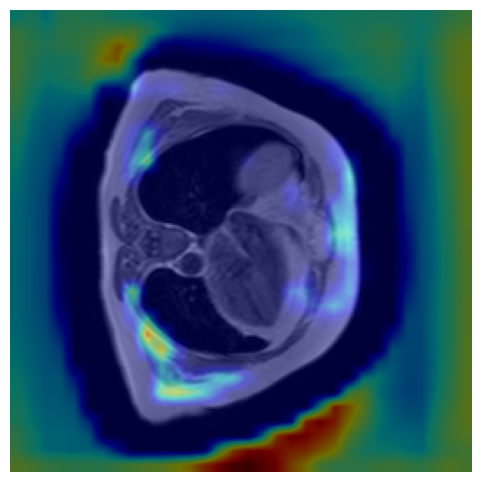

In [25]:
model = AttU_Net(1,5)
model.load_state_dict(torch.load("Att_U_Net_weights30_V2.pth", map_location = torch.device('cpu')))

target_layer = model.Att5

cam = GradCAM(model, target_layer)

image = load_slice("data/MR-dataset/04-T1DUALin-src.nii.gz", 20)

# image : (1,1,H,W)
heatmap = cam(image, class_idx=3)

overlay_cam(image, heatmap)

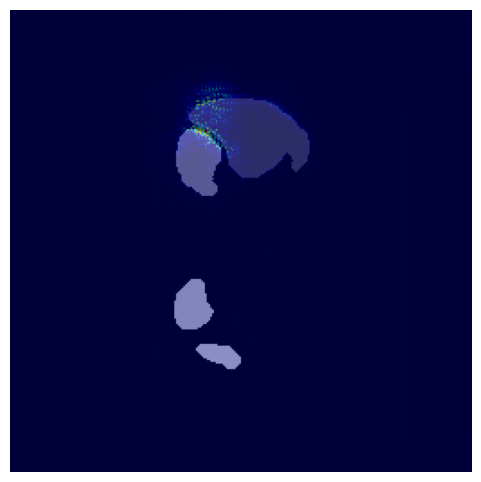

In [13]:
model = U_Net(1,5)
model.load_state_dict(torch.load("U_Net_weights30_V2.pth", map_location = torch.device('cpu')))

image = load_slice("data/MR-dataset/01-T1DUAL-mask.nii.gz", 20)

grad = saliency_map(model, image, class_idx=3)

overlay_cam(image, grad)

In [71]:
nifti_out, volume = predict_volume(AttU_Net(1,5), "models/attU_Net_weights100.pth","data/MR-dataset/01-T1DUALin-src.nii.gz")

<class 'numpy.ndarray'>
(35, 256, 256)


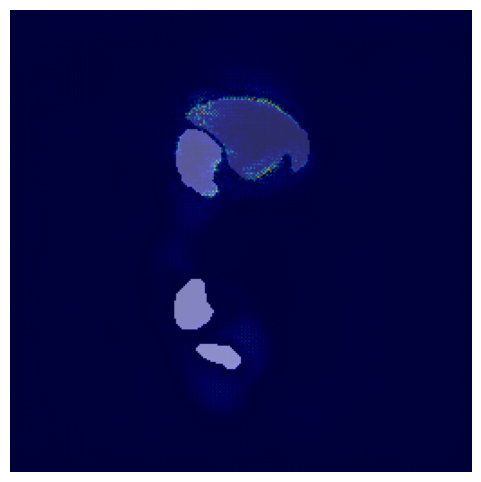

In [8]:
model = AttU_Net(1,5)
model.load_state_dict(torch.load("Att_U_Net_weights30_V2.pth", map_location = torch.device('cpu')))

image = load_slice("data/MR-dataset/01-T1DUAL-mask.nii.gz", 20)

grad = saliency_map(model, image, class_idx=4)

overlay_cam(image, grad)

In [22]:
from losses import dice_per_class_3D
import torch
img = nib.load("data/MR-dataset/01-T1DUAL-mask.nii.gz")
data = img.get_fdata()

data = torch.tensor(data, dtype=torch.float32)
volume = torch.tensor(volume, dtype=torch.float32)

data = data.permute(2,0,1)
print(volume.shape)
volume = volume.permute(2,0,1)

unique_vals = torch.unique(data)


# Appliquer le mapping
mapped = torch.bucketize(data, unique_vals)

print(mapped.shape)
print(volume.shape)

torch.Size([256, 256, 35])
torch.Size([35, 256, 256])
torch.Size([35, 256, 256])


In [23]:
dice = dice_per_class_3D(volume, mapped, 5)

print(dice)

tensor([0.0535, 0.9860, 0.2654, 0.4173, 0.2606])
